## Распределения метрик и выбор статистики

На прошлом семинаре мы считали размер выборки, подставляя в формулу дисперсию метрики. Формула работала одинаково для среднего чека и для конверсии, но за ней стояли две предпосылки: что сравнивать нужно именно средние и что оценка среднего распределена нормально.
Сегодня проверяем обе.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.autolayout': False,
})

BLUE, ORANGE, GREY = '#2E5EAA', '#E4572E', '#8C8C8C'

### Данные

Синтетический недельный срез сервиса доставки еды в двух таблицах. В `users` одна строка на пользователя: выручка, число заказов, число обращений в поддержку. В `orders` одна строка на заказ: время доставки в минутах. Генератор параметризован так, чтобы воспроизвести типичные для этих метрик формы распределений.

In [2]:
def make_users(n, seed=0, buyer_lift=0.0):

    rng = np.random.default_rng(seed)

    is_buyer = rng.random(n) < 0.30 + buyer_lift

    revenue = np.where(is_buyer, rng.lognormal(mean=6.6, sigma=1.1, size=n), 0.0)

    is_corporate = rng.random(n) < 0.005
    revenue = np.where(is_corporate & (revenue > 0),
                       revenue * rng.lognormal(mean=2.5, sigma=1.2, size=n), revenue)

    orders = np.where(is_buyer, rng.negative_binomial(n=1.2, p=0.35, size=n) + 1, 0)

    support = rng.poisson(0.08, size=n)

    return pd.DataFrame({
        'user_id': np.arange(n),
        'is_buyer': is_buyer,
        'is_corporate': is_corporate,
        'revenue': revenue.round(2),
        'orders': orders,
        'support_tickets': support,
    })


def make_orders(users, seed=0, speedup=0.0, delay_cut=0.0):

    rng = np.random.default_rng(seed)

    buyers = users.loc[users.orders > 0, ['user_id', 'orders']]
    user_id = np.repeat(buyers.user_id.to_numpy(), buyers.orders.to_numpy())
    n = len(user_id)

    user_base = dict(zip(buyers.user_id,
                         rng.lognormal(mean=np.log(32), sigma=0.20, size=len(buyers))))
    base = np.array([user_base[u] for u in user_id])

    regular = base * rng.lognormal(mean=0.0, sigma=0.15, size=n) * (1 - speedup)
    is_delayed = rng.random(n) < 0.04
    delay = np.where(is_delayed, rng.exponential(scale=45, size=n), 0.0) * (1 - delay_cut)

    return pd.DataFrame({
        'order_id': np.arange(n),
        'user_id': user_id,
        'delivery_min': (regular + delay).round(1),
    })

In [3]:
users = make_users(20000, seed=1)
orders = make_orders(users, seed=1)

In [4]:
users.head()

,user_id,is_buyer,is_corporate,revenue,orders,support_tickets
0,0,False,False,0.00,0,0
1,1,False,False,0.00,0,0
2,2,True,False,294.27,4,0
3,3,False,False,0.00,0,0
4,4,False,False,0.00,0,0


In [5]:
users.shape

(20000, 6)

In [31]:
users.user_id.nunique()

20000

In [6]:
orders.head()

,order_id,user_id,delivery_min
0,0,2,29.3
1,1,2,44.4
2,2,2,34.2
3,3,2,32.0
4,4,9,39.6


In [32]:
orders.shape

(19535, 3)

In [8]:
pd.concat([
    users[['revenue', 'orders', 'support_tickets']].describe().T,
    orders[['delivery_min']].describe().T,
])[['count', 'mean', 'std', 'min', '50%', 'max']].round(2)

,count,mean,std,min,50%,max
revenue,20000.0,431.06,1693.36,0.0,0.0,71961.98
orders,20000.0,0.98,2.03,0.0,0.0,20.00
support_tickets,20000.0,0.08,0.28,0.0,0.0,3.00
delivery_min,19535.0,34.82,15.13,12.6,32.3,344.00


### 1. Формы распределений продуктовых метрик

Четыре типичные формы, каждая со своей проблемой для анализа.

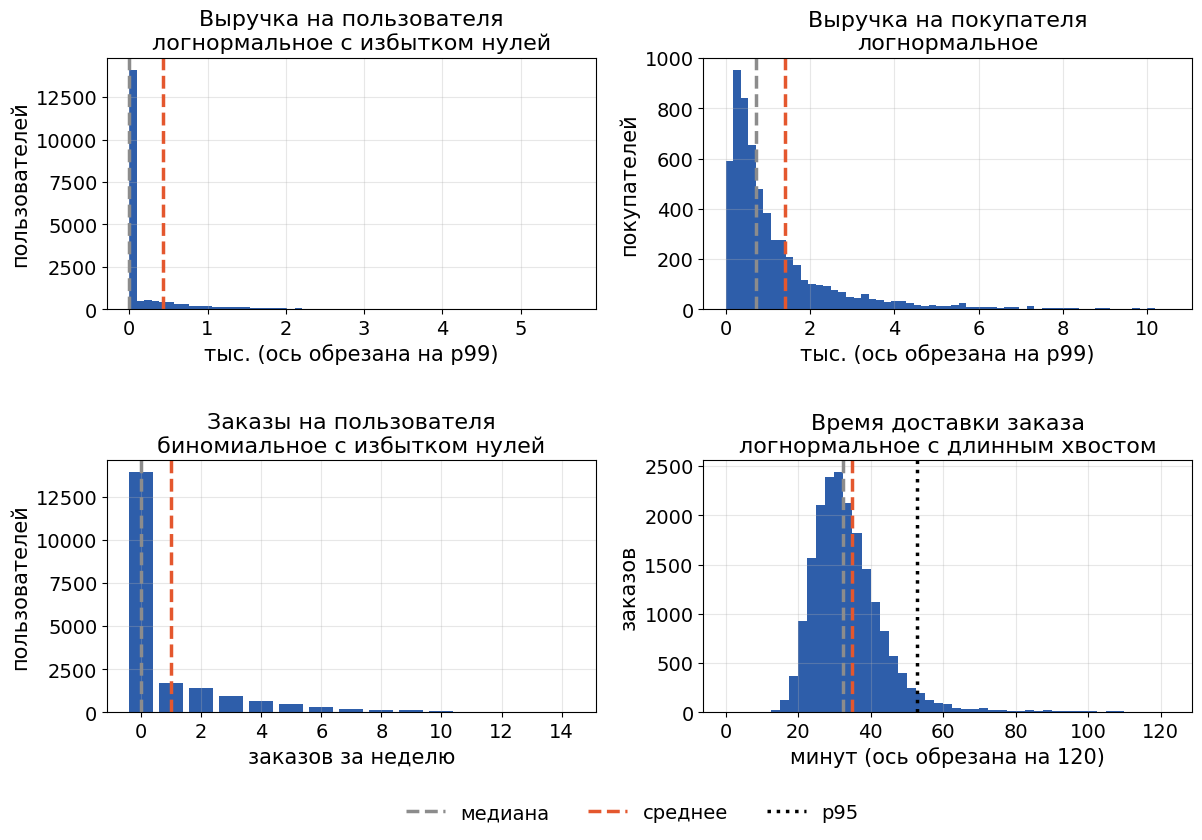

In [9]:
def mark_center(ax, values):
    ax.axvline(np.median(values), color=GREY, ls='--', lw=2.5, label='медиана')
    ax.axvline(np.mean(values), color=ORANGE, ls='--', lw=2.5, label='среднее')


fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))

ax = axes[0, 0]
ax.hist(users['revenue'], bins=np.linspace(0, users['revenue'].quantile(0.99), 60), color=BLUE)
mark_center(ax, users['revenue'])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}'))
ax.set_title('Выручка на пользователя\nлогнормальное с избытком нулей')
ax.set_xlabel('тыс. (ось обрезана на p99)')
ax.set_ylabel('пользователей')

ax = axes[0, 1]
buyers_revenue = users.loc[users.is_buyer, 'revenue']
ax.hist(buyers_revenue, bins=np.linspace(0, buyers_revenue.quantile(0.99), 60), color=BLUE)
mark_center(ax, buyers_revenue)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}'))
ax.set_title('Выручка на покупателя\nлогнормальное')
ax.set_xlabel('тыс. (ось обрезана на p99)')
ax.set_ylabel('покупателей')

ax = axes[1, 0]
counts = users['orders'].value_counts().sort_index()
ax.bar(counts.index[:15], counts.values[:15], color=BLUE)
mark_center(ax, users['orders'])
ax.set_xticks(range(0, 15, 2))
ax.set_title('Заказы на пользователя\nбиномиальное с избытком нулей')
ax.set_xlabel('заказов за неделю')
ax.set_ylabel('пользователей')

ax = axes[1, 1]
ax.hist(orders['delivery_min'], bins=np.arange(0, 125, 2.5), color=BLUE)
mark_center(ax, orders['delivery_min'])
ax.axvline(orders['delivery_min'].quantile(0.95), color='black', ls=':', lw=2.5, label='p95')
ax.set_title('Время доставки заказа\nлогнормальное с длинным хвостом')
ax.set_xlabel('минут (ось обрезана на 120)')
ax.set_ylabel('заказов')

for ax in axes.ravel():
    ax.title.set_fontsize(16)
    ax.grid(alpha=0.3)

handles, labels = axes[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.subplots_adjust(hspace=0.6, wspace=0.22)
plt.show()

| Метрика | Распределение | Как устроено |
|---|---|---|
| Конверсия в покупку | Бернулли | два значения, 0 и 1; все определяется долей $p$ |
| Обращения в поддержку | Пуассона | счетчик редких независимых событий; дисперсия равна среднему |
| Заказы на пользователя | биномиальное с избытком нулей | счетчик, у которого дисперсия больше среднего, потому что пользователи сильно различаются по активности; плюс отдельная масса тех, кто не заказал ни разу |
| Выручка на покупателя | логнормальное | логарифм величины распределен нормально; длинный правый хвост |
| Выручка на пользователя | логнормальное с избытком нулей | смесь — доля не купивших и логнормальное у покупателей |
| Время доставки заказа | логнормальное с длинным хвостом | компактное ядро обычных заказов и редкие долгие заказы из другого режима |

In [10]:
def distribution_profile(metrics):
    rows = []
    
    for name, values in metrics.items():
        x = np.asarray(values, dtype=float)
        top_k = int(np.ceil(0.01 * len(x)))
        rows.append({
            'метрика': name,
            'доля нулей': (x == 0).mean(),
            'среднее': x.mean(),
            'медиана': np.median(x),
            'p99': np.quantile(x, 0.99),
            'skewness': stats.skew(x),
            'доля суммы у топ-1%': np.sort(x)[-top_k:].sum() / x.sum(),
        })
    return pd.DataFrame(rows).set_index('метрика').round(3)


distribution_profile({
    'выручка на пользователя': users['revenue'],
    'выручка на покупателя': users.loc[users.is_buyer, 'revenue'],
    'заказы на пользователя': users['orders'],
    'обращения в поддержку': users['support_tickets'],
    'время доставки заказа': orders['delivery_min'],
})

,доля нулей,среднее,медиана,p99,skewness,доля суммы у топ-1%
метрика,,,,,,
выручка на пользователя,0.697,431.058,0.000,5676.941,17.555,0.271
выручка на покупателя,0.000,1420.757,712.325,10529.408,11.232,0.153
заказы на пользователя,0.697,0.977,0.000,9.000,2.969,0.119
обращения в поддержку,0.925,0.079,0.000,1.000,3.656,0.173
время доставки заказа,0.000,34.824,32.300,95.132,5.941,0.040


**Асимметрия (skewness)** измеряет, насколько распределение перекошено относительно своего среднего:

$$
\text{skewness} = \frac{\mathbb{E}\left[(X - \mu)^3\right]}{\sigma^3}
$$

У симметричного распределения она равна нулю, положительные значения означают длинный правый хвост. Куб в числителе делает её очень чувствительной к редким большим значениям.

Три признака, на которые стоит смотреть всегда:

- **Доля нулей.** Если она велика, метрика фактически состоит из двух: «стал ли пользователь активным» и «сколько принес активный». Движение среднего не говорит, какая из них изменилась. Сравните первые две строки: одни и те же деньги, но с нулями асимметрия вырастает с 11 до 17.5.
- **Доля суммы у верхнего процента.** Один процент пользователей даёт 27% выручки. Дисперсия метрики определяется именно ими, и размер выборки тоже.
- **Хвост, а не разница среднего и медианы.** Привычная проверка «среднее заметно больше медианы» ненадежна. У времени доставки среднее 34.8 и медиана 32.3 почти совпадают, и по ним распределение выглядит спокойным. Хвост виден только в p99 (95 минут, втрое больше медианы) и в асимметрии 5.9.

### 2. Выбор статистики и ее бизнес-смысл

Одно и то же распределение можно описать разными числами, и они отвечают на разные вопросы.

In [11]:
def revenue_statistics(x):
    x = np.asarray(x, dtype=float)
    buyers = x[x > 0]
    return pd.Series({
        'среднее на пользователя': x.mean(),
        'доля покупателей': (x > 0).mean(),
        'среднее на покупателя': buyers.mean(),
        'медиана на покупателя': np.median(buyers),
        'p95 на покупателя': np.quantile(buyers, 0.95),
    })


def delivery_statistics(x, threshold=60):
    x = np.asarray(x, dtype=float)
    return pd.Series({
        'среднее': x.mean(),
        'медиана': np.median(x),
        'p95': np.quantile(x, 0.95),
        'p99': np.quantile(x, 0.99),
        f'доля дольше {threshold} мин, %': (x > threshold).mean() * 100,
    })

In [12]:
revenue_statistics(users['revenue']).round(2).to_frame('выручка')

,выручка
среднее на пользователя,431.06
доля покупателей,0.30
среднее на покупателя,1420.76
медиана на покупателя,712.32
p95 на покупателя,4566.66


In [13]:
delivery_statistics(orders['delivery_min']).round(2).to_frame('время доставки')

,время доставки
среднее,34.82
медиана,32.30
p95,52.80
p99,95.13
"доля дольше 60 мин, %",2.99


| Статистика | На какой вопрос отвечает | Когда выбирать |
|---|---|---|
| Среднее | сколько всего денег принесет изменение | метрика аддитивна и связана с P&L: выручка, заказы, издержки |
| Медиана | что происходит с типичным пользователем | опыт пользователя, а не сумма: время доставки, число шагов |
| Высокий квантиль (p95, p99) | какой худший опыт пользователей | метрики качества и скорости, где важен хвост: время ответа, время ожидания |
| Доля выше порога | у скольких пользователей опыт хуже допустимого | когда у бизнеса есть SLA или понятный порог |
| Среднее по активным | как изменилось поведение тех, кто и так пользуется | когда нули означают, что юзер «не попал в сценарий» |

Ключевое правило: **деньги суммируются, опыт нет**. Проверим обе половины на данных. В каждой паре сценариев среднее меняется одинаково.

In [14]:
def compare_scenarios(base, scenarios, summary_fn):
    table = pd.DataFrame({'базовый': summary_fn(base)})
    for name, values in scenarios.items():
        table[name] = summary_fn(values)
        table[f'Δ {name[0]}, %'] = (table[name] / table['базовый'] - 1) * 100
    return table.round(2)


base = users['revenue'].to_numpy()

# Вариант А: увеличим выручку каждого покупателя на +10%
scenario_a = base * 1.10

# Вариант B: увеличим выручку только топ-1% покупателей на +37%
is_top = base >= np.quantile(base, 0.99)
tail_boost = 0.10 * base.sum() / base[is_top].sum()
scenario_b = np.where(is_top, base * (1 + tail_boost), base)

compare_scenarios(base, {
    'A: +10% всем покупателям': scenario_a,
    f'B: +{tail_boost:.0%} верхнему 1%': scenario_b,
}, revenue_statistics)

,базовый,A: +10% всем покупателям,"Δ A, %",B: +37% верхнему 1%,"Δ B, %"
среднее на пользователя,431.06,474.16,10.0,474.16,10.0
доля покупателей,0.30,0.30,0.0,0.30,0.0
среднее на покупателя,1420.76,1562.83,10.0,1562.83,10.0
медиана на покупателя,712.32,783.56,10.0,712.32,0.0
p95 на покупателя,4566.66,5023.33,10.0,4566.66,0.0


Компания в обоих сценариях заработала одинаково, и среднее это показывает. Медиана и p95 видят только сценарий A. Если бы метрикой эксперимента была медиана, в сценарии B мы бы не увидели реальные деньги. 

Поэтому **для выручки замены среднему нет**: только оно переводится в реальный финансовый прирост.

In [15]:
delivery = orders['delivery_min'].to_numpy()

# Вариант C: каждый заказ доставляется на 2.8% быстрее
scenario_c = make_orders(users, seed=1, speedup=0.028)['delivery_min'].to_numpy()

# Вариант D: обычные заказы без изменений, больше часа — вдвое короче
scenario_d = make_orders(users, seed=1, delay_cut=0.5)['delivery_min'].to_numpy()

compare_scenarios(delivery, {
    'C: все на 2.8% быстрее': scenario_c,
    'D: задержки в два раза короче': scenario_d,
}, delivery_statistics)

,базовый,C: все на 2.8% быстрее,"Δ C, %",D: задержки в два раза короче,"Δ D, %"
среднее,34.82,33.90,-2.65,33.90,-2.65
медиана,32.30,31.40,-2.79,32.20,-0.31
p95,52.80,51.40,-2.65,51.00,-3.41
p99,95.13,94.27,-0.91,69.30,-27.15
"доля дольше 60 мин, %",2.99,2.75,-8.21,1.98,-33.85


По среднему сценарии снова неразличимы: доставка ускорилась на минуту. Но в сценарии C каждый получил заказ на минуту раньше и вряд ли это заметил, а в сценарии D треть заказов, которые ехали дольше часа, теперь доезжают в 2 раза быстрее. Для пользователя это разные продукты, и среднее эту разницу скрывает. Минуты разных заказов не складываются в общий результат так, как складываются деньги.

### 3. Критерий под выбранную статистику

Статистика выбрана, теперь нужен тест, который сравнит ее между группами. Начнем со среднего — его тестируют чаще всего.

#### 3.1. Среднее: t-тест и тяжелый хвост

Для сравнения средних есть два варианта $t$-теста. Оба делят разность средних на ее стандартную ошибку и различаются тем, как эту ошибку оценивают:

- **Критерий Стьюдента** предполагает, что дисперсии в группах равны, и оценивает одну общую дисперсию по объединенным данным.
- **Критерий Уэлча** этого не предполагает и использует дисперсию каждой группы отдельно:

$$
t = \frac{\bar{X}_B - \bar{X}_A}{\sqrt{\dfrac{s_A^2}{n_A} + \dfrac{s_B^2}{n_B}}}
$$

Изменение в продукте может сдвинуть не только среднее, но и вариацию, поэтому на практике по умолчанию берут Уэлча: он ничего не стоит и страхует от этого случая. В `scipy` это параметр `equal_var=False`; дальше используем его.

Оба критерия опираются на ЦПТ: среднее выборки распределено приблизительно нормально при достаточно большом $n$. Сколько будет достаточно зависит от формы распределения: чем сильнее асимметрия, тем медленнее сходимость. Посмотрим, как выглядит распределение среднего выручки при разных размерах группы и что происходит с разностью средних двух групп.

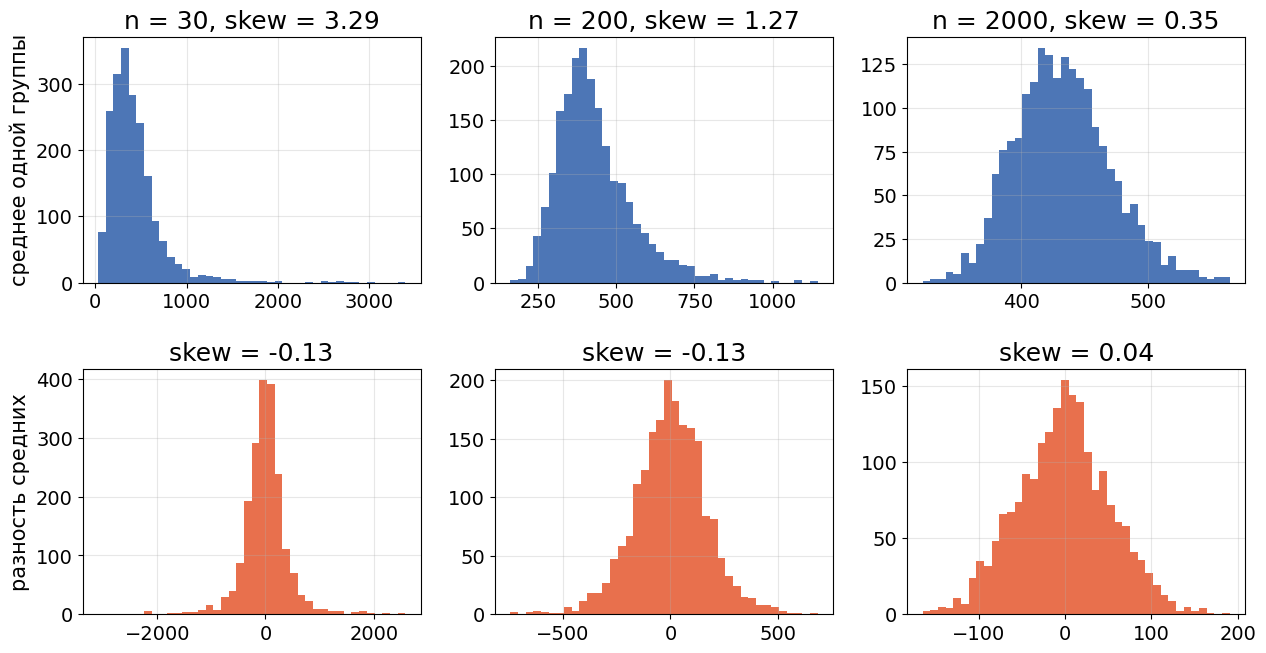

In [16]:
def welch_ttest(a, b):
    res = stats.ttest_ind(b, a, equal_var=False)
    return {'эффект': b.mean() - a.mean(), 'p-value': res.pvalue}


def sampling_distribution(values, n, n_sim=2000, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_sim, n))
    return values[idx].mean(axis=1)


revenue = users['revenue'].to_numpy()
sizes = [30, 200, 2000]

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for col, n in enumerate(sizes):
    mean_a = sampling_distribution(revenue, n, seed=7)
    mean_b = sampling_distribution(revenue, n, seed=8)

    ax = axes[0, col]
    ax.hist(mean_a, bins=40, color=BLUE, alpha=0.85)
    ax.set_title(f'n = {n}, skew = {stats.skew(mean_a):.2f}')

    ax = axes[1, col]
    ax.hist(mean_b - mean_a, bins=40, color=ORANGE, alpha=0.85)
    ax.set_title(f'skew = {stats.skew(mean_b - mean_a):.2f}')

axes[0, 0].set_ylabel('среднее одной группы')
axes[1, 0].set_ylabel('разность средних')
for ax in axes.ravel():
    ax.grid(alpha=0.3)
plt.subplots_adjust(hspace=0.35, wspace=0.22)
plt.show()

Верхний ряд: при $n = 30$ распределение среднего само скошено вправо (асимметрия 3.3), к $n = 2000$ оно выравнивается (0.35).   
Обратите внимание: **нормальность исходной выручки для этого не нужна, гистограмма выручки останется скошенной при любом $n$!**

Нижний ряд: разность средних двух групп симметрична уже при малых $n$. Обе группы скошены одинаково, и при вычитании асимметрия сокращается.

Для первой картины есть известный ориентир из Kohavi et al. (2014): среднее можно считать нормальным при

$$
n > 355 \cdot \text{skewness}^2
$$

In [17]:
skew = stats.skew(revenue)
n_min = int(np.ceil(355 * skew ** 2))

print(f'Асимметрия выручки: {skew:.2f}')
print(f'Требуемый размер группы по правилу: {n_min:,}'.replace(',', ' '))

Асимметрия выручки: 17.56
Требуемый размер группы по правилу: 109 406


Для нашей выручки это 109 тыс. юзеров на группу. Но распределение разности средних подсказывает, что для сравнения двух равных групп требование может оказаться сильно завышенным. Проверим напрямую: многократно разобьем исторические данные на две группы без всякого эффекта и посмотрим, как часто тест находит различие. У корректного критерия эта доля близка к $\alpha$.

In [33]:
def simulate_tests(values, n_per_group, test_fn, effect=0.0, n_sim=2000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(n_sim):
        sample = rng.choice(values, size=2 * n_per_group, replace=True)
        a, b = sample[:n_per_group], sample[n_per_group:] * (1 + effect)
        hits += test_fn(a, b)['p-value'] < alpha
    return hits / n_sim


pd.DataFrame([
    {'n на группу': n, 'доля ложных срабатываний': simulate_tests(revenue, n, welch_ttest, seed=11)}
    for n in [100, 1000, 10000]
]).set_index('n на группу')

,доля ложных срабатываний
n на группу,
100,0.0370
1000,0.0495
10000,0.0440


При 2000 симуляций случайный разброс самой оценки около $\pm 0.01$, так что значения 0.044 и 0.050 от номинальных 0.05 не отличаются. При $n = 100$ тест даже осторожнее, чем заявлено: крупный покупатель, попав в группу, раздувает и разность средних, и оценку дисперсии, и статистика остается небольшой.

Тяжелый хвост не ломает уровень ошибки первого рода. Он бьет по **мощности**. Добавим тестовой группе синтетический эффект и посмотрим, как часто тест его находит.

In [19]:
pd.DataFrame([
    {'n на группу': n,
     **{f'эффект +{effect:.0%}': simulate_tests(revenue, n, welch_ttest, effect=effect,
                                                n_sim=1000, seed=5)
        for effect in [0.02, 0.05, 0.10]}}
    for n in [100, 1000, 2000, 10000, 20000, 100000, n_min]
]).set_index('n на группу')

,эффект +2%,эффект +5%,эффект +10%
n на группу,,,
100,0.032,0.033,0.038
1000,0.038,0.054,0.079
2000,0.040,0.055,0.112
10000,0.056,0.143,0.419
20000,0.076,0.252,0.682
100000,0.219,0.774,1.000
109406,0.215,0.823,1.000


Рост выручки на 5% для бизнеса большое событие, но при 20 тыс. юзеров на группу тест находит его в одном эксперименте из четырех. Даже 100 тыс. на группу не дают привычных 80% мощности. Хвост не делает выводы неверными, он делает эксперимент бессмысленно долгим.

Правило $355 \cdot \text{skew}^2$ поэтому стоит читать как ориентир, а не как критерий допуска. Настоящая проверка — A/A на тех данных и том размере групп, с которыми вы собираетесь работать.

**Неравное разбиение**

Результат выше получен для групп равного размера, и это важно. Асимметрия сокращается в разности только тогда, когда обе группы скошены одинаково. Если группы разные, например 90% пользователей в контроле и 10% в тесте, среднее большой группы уже почти нормально, а среднее маленькой еще скошено, и сокращаться нечему. Повторим A/A для такого разбиения. Эффекта между группами по-прежнему нет, поэтому любое значимое различие ложное; дополнительно посмотрим, в какую сторону тест ошибается.

In [20]:
def aa_unequal(values, n_a, n_b, n_sim=4000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    up = down = 0
    for _ in range(n_sim):
        a = rng.choice(values, size=n_a)
        b = rng.choice(values, size=n_b)
        res = stats.ttest_ind(b, a, equal_var=False)
        if res.pvalue < alpha:
            up += res.statistic > 0
            down += res.statistic < 0
    return {'всего': (up + down) / n_sim, 'тест лучше': up / n_sim, 'тест хуже': down / n_sim}


pd.DataFrame({
    f'{n_a} / {n_b}': aa_unequal(revenue, n_a, n_b, seed=3)
    for n_a, n_b in [(1000, 1000), (1800, 200), (10000, 10000), (18000, 2000)]
}).T

,всего,тест лучше,тест хуже
1000 / 1000,0.04825,0.02550,0.02275
1800 / 200,0.09450,0.00250,0.09200
10000 / 10000,0.04550,0.02200,0.02350
18000 / 2000,0.07100,0.00975,0.06125


При равных группах доля ложных срабатываний близка к 0.05, и ошибки делятся поровну между направлениями. При разбиении 90/10 картина другая:
- Ложных срабатываний становится больше: 0.095 при общей выборке в 2 тысячи и 0.071 при 20 тысячах. Рост выборки в десять раз проблему не снимает.
- Почти все ошибки направлены в одну сторону: тест детектирует, что маленькая группа хуже.

#### 3.2. Доля и квантиль

**Доля.** Для бинарной метрики дисперсия полностью определяется самой долей, $p(1-p)$, хвостов нет, и достаточно $z$-критерия:

$$
z = \frac{\hat{p}_B - \hat{p}_A}{\sqrt{\hat{p}(1-\hat{p})\left(\dfrac{1}{n_A} + \dfrac{1}{n_B}\right)}}
$$

где $\hat{p}$ — доля по объединенным данным. Пример: изменение подняло конверсию в покупку на один процентный пункт.

In [21]:
def proportion_ztest(a, b):

    p_a, p_b = a.mean(), b.mean()
    p_pool = (a.sum() + b.sum()) / (len(a) + len(b))
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / len(a) + 1 / len(b)))
    z = (p_b - p_a) / se
    return {'эффект': float(p_b - p_a), 'p-value': float(2 * (1 - stats.norm.cdf(abs(z))))}


control_users = make_users(20_000, seed=101)
test_users = make_users(20_000, seed=202, buyer_lift=0.01)

print(f"Доля покупателей: контроль {control_users['is_buyer'].mean():.1%}, тест {test_users['is_buyer'].mean():.1%}")
proportion_ztest(control_users['is_buyer'].to_numpy(), test_users['is_buyer'].to_numpy())

Доля покупателей: контроль 29.8%, тест 31.0%


{'эффект': 0.011750000000000038, 'p-value': 0.01063393399800483}

Проверим $z$-критерий на A/A для доли покупателей при 100, 1000 и 10 000 пользователей на группу.

In [22]:
is_buyer = users['is_buyer'].to_numpy().astype(float)

pd.DataFrame([
    {'n на группу': n, 'доля ложных срабатываний': simulate_tests(is_buyer, n, proportion_ztest, seed=11)}
    for n in [100, 1000, 10_000]
]).set_index('n на группу')

,доля ложных срабатываний
n на группу,
100,0.0525
1000,0.0465
10000,0.0480


Почему требования к выборке здесь принципиально другие, чем для выручки?

**Квантиль.** Для разности квантилей удобной формулы стандартной ошибки нет, поэтому ее получают бутстрапом: много раз перевыбирают данные с возвращением, каждый раз пересчитывают статистику и смотрят на разброс результатов. Интервал между 2.5-м и 97.5-м перцентилем этих значений и есть доверительный интервал.

Важная деталь для нашего примера: рандомизация идет по пользователям, а время доставки измеряется по заказам. Заказы одного пользователя похожи между собой, поэтому перевыбирать нужно пользователей целиком, вместе со всеми их заказами. Это та же проблема, что с ratio-метриками на прошлом семинаре.

In [23]:
def bootstrap_quantile_test(a, b, q=0.5, by_user=True, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)

    def boot_quantiles(df):
        values = df['delivery_min'].to_numpy()
        if not by_user:
            idx = rng.integers(0, len(values), size=(n_boot, len(values)))
            return np.quantile(values[idx], q, axis=1)
        user_idx = pd.factorize(df['user_id'])[0]
        n_users = user_idx.max() + 1
        result = np.empty(n_boot)
        for i in range(n_boot):
            counts = np.bincount(rng.integers(0, n_users, size=n_users), minlength=n_users)
            result[i] = np.quantile(np.repeat(values, counts[user_idx]), q)
        return result

    diff = boot_quantiles(b) - boot_quantiles(a)
    ci = np.quantile(diff, [0.025, 0.975])
    p = 2 * min((diff <= 0).mean(), (diff >= 0).mean())
    effect = np.quantile(b['delivery_min'], q) - np.quantile(a['delivery_min'], q)
    return {'эффект': round(float(effect), 1),
            'CI 95%': (round(float(ci[0]), 1), round(float(ci[1]), 1)),
            'p-value': float(np.clip(p, 1 / n_boot, 1.0))}

Эксперимент: в тестовой группе задержки вдвое короче

In [24]:
control_orders = make_orders(make_users(20_000, seed=101), seed=101)
test_orders = make_orders(make_users(20_000, seed=202), seed=202, delay_cut=0.5)

pd.DataFrame({
    name: bootstrap_quantile_test(control_orders, test_orders, q=q)
    for name, q in [('медиана', 0.5), ('p95', 0.95), ('p99', 0.99)]
}).T

,эффект,CI 95%,p-value
медиана,0.1,"(-0.2, 0.5)",0.47
p95,-0.8,"(-1.8, 0.0)",0.06
p99,-24.6,"(-30.7, -17.5)",0.001


Медиана эффекта не видит, p95 на границе, p99 показывает сокращение на 25 минут с уверенным интервалом. Выбор квантиля определяет, увидим ли мы эффект вообще, и сделать этот выбор нужно до эксперимента, исходя из того, где именно мы ждем изменение.

Теперь проверим на A/A, действительно ли важно перевыбирать пользователей. Ячейка считается около минуты.

In [25]:
def aa_bootstrap(q, by_user, n_users=3000, n_sim=300, n_boot=300, alpha=0.05):
    hits = 0
    for i in range(n_sim):
        a = make_orders(make_users(n_users, seed=1000 + 2 * i), seed=1000 + 2 * i)
        b = make_orders(make_users(n_users, seed=1001 + 2 * i), seed=1001 + 2 * i)
        hits += bootstrap_quantile_test(a, b, q=q, by_user=by_user, n_boot=n_boot, seed=i)['p-value'] < alpha
    return hits / n_sim


pd.Series({
    'бутстрап по заказам': aa_bootstrap(0.95, by_user=False),
    'бутстрап по пользователям': aa_bootstrap(0.95, by_user=True),
}, name='доля ложных срабатываний, p95').to_frame()

,"доля ложных срабатываний, p95"
бутстрап по заказам,0.100000
бутстрап по пользователям,0.046667


Бутстрап по заказам ошибается вдвое чаще заявленного: он считает все заказы независимыми наблюдениями, хотя независимых единиц втрое меньше, это пользователи. Интервал из-за этого выходит слишком узким. По той же причине долю заказов дольше 60 минут нельзя проверять $z$-критерием по заказам: это ratio-метрика, и для нее нужны дельта-метод, линеаризация или тот же бутстрап по пользователям.

#### 3.3. Критерий Манна–Уитни

Критерий Манна–Уитни обычно описывают как тест для сравнения медиан, но проверяет он другую гипотезу: $P(X < Y) = 1/2$, то есть что случайный пользователь теста с равной вероятностью окажется выше или ниже случайного пользователя контроля. К равенству медиан это сводится только тогда, когда распределения в группах одинаковы по форме и различаются лишь сдвигом, а изменения в продукте обычно меняют форму: долю нулей, хвост. 

Наша выручка хороший контрпример: ее медиана равна нулю в обеих группах при любом эффекте, а критерий при этом может показать различие. Значимый результат к тому же не говорит, на сколько выросла выручка, поэтому для денежных метрик критерий не подходит; его место там, где метрика порядковая и не аддитивная: оценки, рейтинги, баллы удовлетворенности.

### 4. Работа с выбросами: кейс дизайна эксперимента

Планируем эксперимент на выручке на пользователя и хотим ловить эффект 5%. В 3.1 мы видели, что хвост съедает мощность. При планировании у него есть и второе следствие. Возьмtм восемь недель истории и посчитаем размер выборки по каждой.

In [26]:
def sample_size(x, mde=0.05, alpha=0.05, power=0.80):
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return int(np.ceil(2 * x.var(ddof=1) * z ** 2 / (mde * x.mean()) ** 2))


weeks = {week: make_users(20_000, seed=week) for week in range(1, 9)}

pd.DataFrame([
    {'неделя': week,
     'среднее': df['revenue'].mean(),
     'std': df['revenue'].std(),
     'максимум': df['revenue'].max(),
     'n на группу для MDE 5%': sample_size(df['revenue'].to_numpy())}
    for week, df in weeks.items()
]).set_index('неделя').round(0).astype(int)

,среднее,std,максимум,n на группу для MDE 5%
неделя,,,,
1,431,1693,71962,96901
2,440,1957,162860,124003
3,415,1402,60782,71580
4,468,4630,487273,615544
5,468,4218,459453,511141
6,439,2183,159802,155180
7,459,3212,292193,307057
8,523,9652,1148670,2141911


Среднее от недели к неделе меняется на четверть, а требуемый размер выборки в тридцать раз: от 72 тысяч до 2.1 миллиона на группу. Все определяется тем, попал ли в неделю один очень крупный заказ. Планировать эксперимент по такой метрике нельзя: ответ зависит от того, какую неделю мы взяли.

#### Первый вопрос: можно ли формально определить, кто здесь выброс? 

Есть три классических правила.

**Правило Тьюки (IQR).** Выбросом считается все, что выше верхней границы:

$$
x > Q_3 + 1.5 \cdot \text{IQR}, \qquad \text{IQR} = Q_3 - Q_1
$$

где $Q_1$ и $Q_3$ — первый и третий квартили.

**Три сигмы.** Выбросом считается все, что дальше трех стандартных отклонений от среднего:

$$
x > \bar{x} + 3s
$$

**MAD.** Устойчивый аналог трех сигм: среднее заменено медианой, а стандартное отклонение — медианой абсолютных отклонений от медианы:

$$
x > \text{med}(x) + 3 \cdot 1.4826 \cdot \text{MAD}, \qquad \text{MAD} = \text{med}\left(\,\left|x_i - \text{med}(x)\right|\,\right)
$$

Множитель 1.4826 приводит MAD к масштабу стандартного отклонения для нормального распределения.

Посмотрим, что дает первое правило на нашей выручке.

In [27]:
history = pd.concat(weeks.values(), ignore_index=True)
x = history['revenue'].to_numpy()
is_corporate = history['is_corporate'].to_numpy()

q1, q3 = np.quantile(x, [0.25, 0.75])
iqr_threshold = q3 + 1.5 * (q3 - q1)

print(f'Порог IQR: {iqr_threshold:.0f}')
print(f'Пользователей выше порога: {(x > iqr_threshold).mean():.1%}')
print(f'Их доля в выручке: {x[x > iqr_threshold].sum() / x.sum():.1%}')

Порог IQR: 649
Пользователей выше порога: 16.6%
Их доля в выручке: 90.1%


Правило Тьюки придумано для распределений, близких к симметричным, и здесь объявляет выбросом каждого шестого пользователя с 90% выручки. Два других правила не лучше. Порог трех сигм сам зависит от выбросов: $s$ меняется от недели к неделе в семь раз, и порог вместе с ним. MAD вырождается: больше половины пользователей ничего не купили, поэтому и медиана, и MAD равны нулю, и выбросом оказывается любой покупатель.

В продуктовых метриках выброс чаще всего не ошибка в данных, а настоящий пользователь с большим заказом. Поэтому порог не вычисляют по формуле, а выбирают: по высокому квантилю или по бизнес-смыслу.

#### Второй вопрос: что делать со значениями выше порога?

Сравним четыре способа.

**Удаление.** Пользователи выше порога выбрасываются из выборки: остаются только $x_i \le c$.

**Винзоризация.** Значения выше порога заменяются самим порогом:

$$
x_i' = \min(x_i,\, c)
$$

**Замена на медиану.** Значения выше порога заменяются типичным значением, у нас это медиана покупателей $m$:

$$
x_i' = \begin{cases} x_i, & x_i \le c \\ m, & x_i > c \end{cases}
$$

**Исключение по бизнес-признаку.** Порог по значению не используется: из выборки целиком убирается сегмент, который по смыслу не относится к метрике. У нас это корпоративные клиенты.

Для каждого способа посмотрим, что он делает с самой метрикой и с тестом.

In [28]:
CAP = np.quantile(x, 0.99)
BUYER_MEDIAN = np.median(x[x > 0])

methods = {
    'без обработки': lambda v, corp: v,
    'удаление': lambda v, corp: v[v <= CAP],
    'винзоризация': lambda v, corp: np.minimum(v, CAP),
    'замена на медиану': lambda v, corp: np.where(v > CAP, BUYER_MEDIAN, v),
    'исключение корпоративных': lambda v, corp: v[~corp],
}


def describe_methods(weeks, methods):
    history = pd.concat(weeks.values(), ignore_index=True)
    values, corp = history['revenue'].to_numpy(), history['is_corporate'].to_numpy()
    rows = []
    for name, method in methods.items():
        processed = method(values, corp)
        sizes = [sample_size(method(df['revenue'].to_numpy(), df['is_corporate'].to_numpy()))
                 for df in weeks.values()]
        rows.append({
            'метод': name,
            'смещение среднего, %': (processed.mean() / values.mean() - 1) * 100,
            'std': processed.std(ddof=1),
            'n для MDE 5%, минимум по неделям': min(sizes),
            'n для MDE 5%, максимум по неделям': max(sizes),
        })
    return pd.DataFrame(rows).set_index('метод')


def compare_methods(values, corp, methods, n_per_group=50_000, effect=0.05,
                    n_sim=500, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    tail_boost = effect * values.sum() / values[values > CAP].sum()
    columns = ['ложные срабатывания', f'мощность: +{effect:.0%} всем',
               'мощность: те же деньги в топ-1%']
    hits = pd.DataFrame(0.0, index=list(methods), columns=columns)

    for _ in range(n_sim):
        idx = rng.integers(0, len(values), size=2 * n_per_group)
        idx_a, idx_b = idx[:n_per_group], idx[n_per_group:]
        a, b = values[idx_a], values[idx_b]
        test_versions = [b, b * (1 + effect), np.where(b > CAP, b * (1 + tail_boost), b)]
        for name, method in methods.items():
            a_processed = method(a, corp[idx_a])
            for column, b_version in zip(columns, test_versions):
                b_processed = method(b_version, corp[idx_b])
                hits.loc[name, column] += welch_ttest(a_processed, b_processed)['p-value'] < alpha
    return hits / n_sim

In [29]:
describe_methods(weeks, methods).join(compare_methods(x, is_corporate, methods)).round(2)

,"смещение среднего, %",std,"n для MDE 5%, минимум по неделям","n для MDE 5%, максимум по неделям",ложные срабатывания,мощность: +5% всем,мощность: те же деньги в топ-1%
метод,,,,,,,
без обработки,0.00,4417.96,71580,2141911,0.04,0.15,0.13
удаление,-29.88,762.90,35427,36340,0.06,0.52,0.06
винзоризация,-18.17,926.26,38314,39381,0.05,0.77,0.05
замена на медиану,-28.96,760.22,34338,35125,0.06,0.56,0.06
исключение корпоративных,-11.55,1252.01,56203,62959,0.05,0.72,0.44


**План.** Любая обработка делает его устойчивым: вместо разброса в тридцать раз между неделями остаются единицы процентов.

**Мощность при эффекте у всех.** Среди методов с порогом лучший — винзоризация: 0.77 против 0.52 у удаления и 0.56 у замены на медиану. Удаление и замена применяются по значению самой метрики, и пользователь теста, которого эффект перенёс через порог, выбрасывается или получает 739 вместо своих 5 700. Часть эффекта при этом вычитается. Винзоризация оставляет его на пороге.

**Мощность при эффекте в хвосте.** Все методы с порогом слепы: мощность равна доле ложных срабатываний. Они отрезали ровно ту часть распределения, где находился эффект, хотя деньги в этом сценарии те же.

**Исключение по бизнес-признаку** выглядит лучше всех: мощность почти как у винзоризации, наименьшее смещение, и это единственный метод, который видит эффект в хвосте. Обычные крупные покупатели остаются в метрике, уходит только сегмент, создававший шум. Условие: признак известен до эксперимента и от теста не зависит.

Порог при этом должен быть одним числом, посчитанным по истории. Если считать p99 отдельно в каждой группе по данным эксперимента, пороги у групп получатся разные:

In [30]:
compare_methods(x, is_corporate, {
    'порог из истории': lambda v, corp: np.minimum(v, CAP),
    'свой порог у каждой группы': lambda v, corp: np.minimum(v, np.quantile(v, 0.99)),
})[['ложные срабатывания']]

,ложные срабатывания
порог из истории,0.046
свой порог у каждой группы,0.102


Доля ложных срабатываний удваивается: порог становится случайной величиной, разной у двух групп, а $t$-тест считает дисперсию так, будто он был задан заранее.

**Правила.**

1. Сначала ищем бизнес-признак, по которому сегмент можно исключить. Если его нет, берем винзоризацию.
2. Порог или признак фиксируется до старта эксперимента, по истории, и одинаков для обеих групп.
3. Обработанная метрика — отдельная метрика с отдельным названием. Ее среднее на 12–30% ниже настоящего, и по ней нельзя отчитываться в деньгах.
4. Рядом всегда остается необработанная версия. Расхождение между ними означает, что эффект сидит в хвосте и его нужно смотреть отдельно, а не выбирать удобную версию.

**То же на уровне дней.** Мы разбирали выброс-пользователя, но при дизайне аномалия в истории бывает и во времени: день с аномальной погодой, сбой в работе сайта, распродажа. Логика та же. Сначала аномалию нужно найти; во временном ряду для этого есть свои методы с учетом тренда и сезонности (критерий Граббса, GESD, STL). Затем обработать: исключить день из окна, по которому оцениваются базовое значение и дисперсия, или заменить его типичным значением, что по смыслу та же винзоризация. С историей при дизайне можно обращаться свободно, потому что по ней мы только планируем. В самом эксперименте аномальный день задевает обе группы одинаково и сравнение не ломает, а исключать его задним числом можно только по правилу, записанному до старта.

### Правило выбора

| Метрика | Форма распределения | Статистика | Критерий | 
|-|---|---|---|
| Конверсия в покупку | бинарная | доля | $z$-критерий для долей |
| Заказы на пользователя | счетная, масса в нуле | среднее | $t$-тест Уэлча |
| Выручка на пользователя | нули и тяжелый хвост | среднее | $t$-тест Уэлча |
| Время доставки, типичный опыт | скошенная, по заказам | медиана | бутстрап по пользователям | 
| Время доставки, худший опыт | скошенная, по заказам | p95, p99 | бутстрап по пользователям |
| Нарушения SLA (пример — доставка за 60 минут) | бинарная по заказам | доля заказов выше порога | дельта-метод, линеаризация или бутстрап по пользователям | 
| Средний чек, CTR | ratio | отношение средних | дельта-метод или линеаризация |
| Оценки, баллы удовлетворённости | порядковая | — | Манна–Уитни 


**Порядок выбора.** Сначала вопрос бизнеса, потом статистика, потом критерий. Метрика и критерий фиксируются до эксперимента. Если критерию не хватает мощности, это причина увеличить выборку, обработать хвост по заранее заданному правилу или сменить дизайн, а не подменить метрику той, что показала значимость.